In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
h1b_information = pd.read_csv(
    '/content/drive/MyDrive/notebooks/Employer_Information.csv',
    encoding='utf-16',
    sep='\t',
    engine='python',
)

Mounted at /content/drive


In [ ]:
h1b_information.columns = h1b_information.columns.str.strip()

In [ ]:
h1b_information.head()

,Line by line,Fiscal Year,Employer (Petitioner) Name,Tax ID,Industry (NAICS) Code,Petitioner City,Petitioner State,Petitioner Zip Code,New Employment Approval,New Employment Denial,Continuation Approval,Continuation Denial,Change with Same Employer Approval,Change with Same Employer Denial,New Concurrent Approval,New Concurrent Denial,Change of Employer Approval,Change of Employer Denial,Amended Approval,Amended Denial
0,1,2025,NaN,NaN,"54 - Professional, Scientific, and Technical S...",FRISCO,TX,75034.0,0,0,0,0,0,0,0,0,1,0,0,0
1,2,2025,NaN,274.0,"54 - Professional, Scientific, and Technical S...",GUILFORD,CT,6437.0,0,0,1,0,0,0,0,0,0,0,0,0
2,3,2025,NaN,305.0,"54 - Professional, Scientific, and Technical S...",WASHINGTON,DC,20001.0,0,0,1,0,0,0,0,0,0,0,0,0
3,4,2025,NaN,3188.0,"54 - Professional, Scientific, and Technical S...",ARLINGTON,TX,76011.0,0,0,0,0,1,0,0,0,0,0,0,0
4,5,2025,NaN,4668.0,"54 - Professional, Scientific, and Technical S...",CHICAGO,IL,60625.0,2,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
h1b_information.columns

Index(['Line by line', 'Fiscal Year', 'Employer (Petitioner) Name', 'Tax ID',
       'Industry (NAICS) Code', 'Petitioner City', 'Petitioner State',
       'Petitioner Zip Code', 'New Employment Approval',
       'New Employment Denial', 'Continuation Approval', 'Continuation Denial',
       'Change with Same Employer Approval',
       'Change with Same Employer Denial', 'New Concurrent Approval',
       'New Concurrent Denial', 'Change of Employer Approval',
       'Change of Employer Denial', 'Amended Approval', 'Amended Denial'],
      dtype='object')

In [ ]:
h1b_information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338891 entries, 0 to 338890
Data columns (total 20 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Line by line                        338891 non-null  object 
 1   Fiscal Year                         338891 non-null  int64  
 2   Employer (Petitioner) Name          338869 non-null  object 
 3   Tax ID                              334739 non-null  float64
 4   Industry (NAICS) Code               338891 non-null  object 
 5   Petitioner City                     338889 non-null  object 
 6   Petitioner State                    338806 non-null  object 
 7   Petitioner Zip Code                 338792 non-null  float64
 8   New Employment Approval             338891 non-null  object 
 9   New Employment Denial               338891 non-null  object 
 10  Continuation Approval               338891 non-null  object 
 11  Continuation Denial       

In [ ]:
h1b_information['Change of Employer Approval'] = pd.to_numeric(
    h1b_information['Change of Employer Approval'], errors='coerce'
)

In [ ]:
industry_fiscal_change = (
    h1b_information.groupby(['Industry (NAICS) Code', 'Fiscal Year'], as_index=False)
    ['Change of Employer Approval']
    .sum()
)
display(industry_fiscal_change)

,Industry (NAICS) Code,Fiscal Year,Change of Employer Approval
0,"11 - Agriculture, Forestry, Fishing and Hunting",2020,26.0
1,"11 - Agriculture, Forestry, Fishing and Hunting",2021,40.0
2,"11 - Agriculture, Forestry, Fishing and Hunting",2022,40.0
3,"11 - Agriculture, Forestry, Fishing and Hunting",2023,271.0
4,"11 - Agriculture, Forestry, Fishing and Hunting",2024,286.0
...,...,...,...
115,92 - Public Administration,2021,119.0
116,92 - Public Administration,2022,115.0
117,92 - Public Administration,2023,105.0
118,92 - Public Administration,2024,97.0


In [ ]:
qualified_industries = (
    industry_fiscal_change
        .groupby("Industry (NAICS) Code")["Change of Employer Approval"]
        .min()
        .loc[lambda x: x >= 500]
        .index
)

filtered_data = industry_fiscal_change[
    industry_fiscal_change["Industry (NAICS) Code"].isin(qualified_industries)
]
display(filtered_data)

,Industry (NAICS) Code,Fiscal Year,Change of Employer Approval
24,31-33 - Manufacturing,2020,7980.0
25,31-33 - Manufacturing,2021,11004.0
26,31-33 - Manufacturing,2022,15470.0
27,31-33 - Manufacturing,2023,10409.0
28,31-33 - Manufacturing,2024,8049.0
29,31-33 - Manufacturing,2025,7714.0
30,42 - Wholesale Trade,2020,756.0
31,42 - Wholesale Trade,2021,795.0
32,42 - Wholesale Trade,2022,1237.0
33,42 - Wholesale Trade,2023,1020.0


In [ ]:
#calculate year to year percent change for each industry

filtered_data = filtered_data.sort_values(
    ["Industry (NAICS) Code", "Fiscal Year"]
)

filtered_data["Percent Change"] = (
    filtered_data.groupby("Industry (NAICS) Code")["Change of Employer Approval"]
    .pct_change()
)

display(filtered_data)

,Industry (NAICS) Code,Fiscal Year,Change of Employer Approval,Percent Change
24,31-33 - Manufacturing,2020,7980.0,NaN
25,31-33 - Manufacturing,2021,11004.0,0.378947
26,31-33 - Manufacturing,2022,15470.0,0.405852
27,31-33 - Manufacturing,2023,10409.0,-0.327149
28,31-33 - Manufacturing,2024,8049.0,-0.226727
29,31-33 - Manufacturing,2025,7714.0,-0.041620
30,42 - Wholesale Trade,2020,756.0,NaN
31,42 - Wholesale Trade,2021,795.0,0.051587
32,42 - Wholesale Trade,2022,1237.0,0.555975
33,42 - Wholesale Trade,2023,1020.0,-0.175424


In [ ]:
filtered_data['Industry (NAICS) Code'].unique()

array(['31-33 - Manufacturing', '42 - Wholesale Trade',
       '44-45 - Retail Trade', '51 - Information',
       '52 - Finance and Insurance',
       '54 - Professional, Scientific, and Technical Services',
       '56 - Administrative and Support and Waste Management and Remediation Services',
       '61 - Educational Services',
       '62 - Health Care and Social Assistance'], dtype=object)

In [ ]:
short_name_map = {
    '31-33 - Manufacturing': 'Manufacturing',
    '42 - Wholesale Trade': 'Wholesale Trade',
    '44-45 - Retail Trade': 'Retail Trade',
    '51 - Information': 'Information',
    '52 - Finance and Insurance': 'Finance and Insurance',
    '54 - Professional, Scientific, and Technical Services': 'Professional, Scientific, and Technical Services',
    '56 - Administrative and Support and Waste Management and Remediation Services': 'Administrative and Waste Management Services',
    '61 - Educational Services': 'Educational Services',
    '62 - Health Care and Social Assistance': 'Health Care and Social Assistance'
}


In [ ]:
filtered_data['Industry (NAICS) Code'] = filtered_data['Industry (NAICS) Code'].replace(short_name_map)

In [ ]:
filtered_data["Industry (NAICS) Code"].unique()

array(['Manufacturing', 'Wholesale Trade', 'Retail Trade', 'Information',
       'Finance and Insurance',
       'Professional, Scientific, and Technical Services',
       'Administrative and Waste Management Services',
       'Educational Services', 'Health Care and Social Assistance'],
      dtype=object)

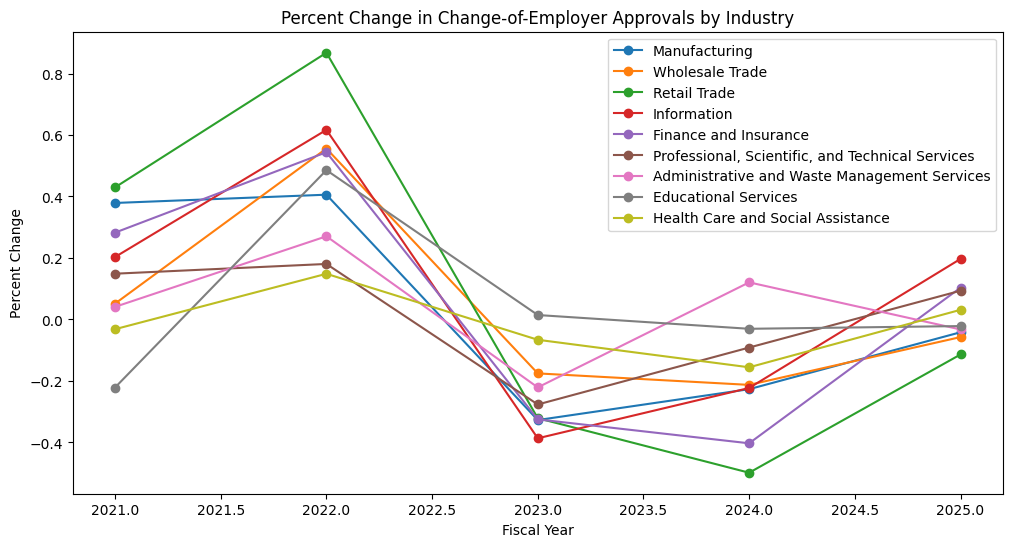

In [ ]:
industries = filtered_data["Industry (NAICS) Code"].unique()
line_graphs = ()
plt.figure(figsize=(12, 6))

for industry in industries:
    industry_data = filtered_data[filtered_data["Industry (NAICS) Code"] == industry]

    plt.plot(industry_data["Fiscal Year"], industry_data["Percent Change"], marker='o', label=industry)


plt.title("Percent Change in Change-of-Employer Approvals by Industry")
plt.xlabel("Fiscal Year")
plt.ylabel("Percent Change")
plt.legend()
plt.show()